In [1]:
import pandas as pd
from pathlib import Path

# Load Italy population data
population_path = Path("../data/italy/population/Population.csv")

italy_population = pd.read_csv(population_path)

# Display the first rows
italy_population.head()

,Age,Total males,Total females,Total
0,0,184283,173890,358173
1,1,192088,181053,373141
2,2,199434,187749,387183
3,3,208557,195140,403697
4,4,212473,201156,413629


In [2]:
# Convert Age and population columns to numeric
italy_population["Age"] = pd.to_numeric(
    italy_population["Age"], errors="coerce"
)

italy_population["Total"] = pd.to_numeric(
    italy_population["Total"], errors="coerce"
)

# Calculate adult population aged 18+
italy_adult_population = italy_population.loc[
    italy_population["Age"] >= 18, "Total"
].sum()

italy_adult_population

np.int64(50327351)

In [3]:
# Create Italy adult population summary
italy_adult_population_summary = pd.DataFrame({
    "Metric": [
        "Adult population (18+)"
    ],
    "Value": [
        italy_adult_population
    ]
})

italy_adult_population_summary

,Metric,Value
0,Adult population (18+),50327351


In [4]:
# Create output folder
output_tables = Path("../reports/italy/tables")
output_tables.mkdir(parents=True, exist_ok=True)

# Save summary table
italy_adult_population_summary.to_csv(
    output_tables / "italy_adult_population_summary.csv",
    index=False
)

print("Saved:", output_tables / "italy_adult_population_summary.csv")

Saved: ..\reports\italy\tables\italy_adult_population_summary.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Project paths
population_path = Path("../data/italy/population/Population.csv")

italy_population = pd.read_csv(population_path)

# Clean column names
italy_population.columns = [
    "Age",
    "Total males",
    "Total females",
    "Total"
]

# Convert columns to numeric
italy_population["Age"] = pd.to_numeric(
    italy_population["Age"],
    errors="coerce"
)

italy_population["Total"] = pd.to_numeric(
    italy_population["Total"],
    errors="coerce"
)

italy_population.head()

,Age,Total males,Total females,Total
0,0.0,184283,173890,358173
1,1.0,192088,181053,373141
2,2.0,199434,187749,387183
3,3.0,208557,195140,403697
4,4.0,212473,201156,413629


In [7]:
# Italy adult population: age 18+
italy_adult_population = italy_population.loc[
    italy_population["Age"] >= 18,
    "Total"
].sum()

# PASSI population range: age 18–69
italy_passi_population = italy_population.loc[
    (italy_population["Age"] >= 18) &
    (italy_population["Age"] <= 69),
    "Total"
].sum()

print(f"Italy adult population (18+): {italy_adult_population:,.0f}")
print(f"Italy population aged 18–69: {italy_passi_population:,.0f}")

Italy adult population (18+): 50,327,351
Italy population aged 18–69: 39,362,629


In [8]:
# Italy adult population: age 18+
italy_adult_population = italy_population.loc[
    italy_population["Age"] >= 18,
    "Total"
].sum()

# PASSI population range: age 18–69
italy_passi_population = italy_population.loc[
    (italy_population["Age"] >= 18) &
    (italy_population["Age"] <= 69),
    "Total"
].sum()

print(f"Italy adult population (18+): {italy_adult_population:,.0f}")
print(f"Italy population aged 18–69: {italy_passi_population:,.0f}")

Italy adult population (18+): 50,327,351
Italy population aged 18–69: 39,362,629


In [9]:
italy_epidemiology_summary = pd.DataFrame({
    "Metric": [
        "Adult population (18+)",
        "Population aged 18–69",
        "Obesity prevalence (18–69)",
        "Estimated adults aged 18–69 with obesity"
    ],
    "Value": [
        italy_adult_population,
        italy_passi_population,
        italy_obesity_prevalence,
        italy_adults_with_obesity
    ]
})

italy_epidemiology_summary

NameError: name 'italy_obesity_prevalence' is not defined

In [10]:
uptake_rates = {
    1: 0.05,
    2: 0.10,
    3: 0.15,
    4: 0.20,
    5: 0.25
}

italy_uptake = pd.DataFrame({
    "Year": list(uptake_rates.keys()),
    "Uptake": list(uptake_rates.values())
})

italy_uptake

,Year,Uptake
0,1,0.05
1,2,0.10
2,3,0.15
3,4,0.20
4,5,0.25


In [11]:
italy_monthly_maintenance_cost = 380.00
italy_cycles_per_year = 13

italy_annual_drug_cost = (
    italy_monthly_maintenance_cost *
    italy_cycles_per_year
)

italy_annual_drug_cost

4940.0

In [12]:
italy_drug_excess_cost = 460.6 - 288.0
italy_hospital_excess_cost = 422.7 - 279.2
italy_outpatient_excess_cost = 283.2 - 251.7

italy_healthcare_offset = (
    italy_drug_excess_cost
    + italy_hospital_excess_cost
    + italy_outpatient_excess_cost
)

print(f"Healthcare cost offset: €{italy_healthcare_offset:,.2f}")

Healthcare cost offset: €347.60


In [13]:
italy_annual_healthcare_offset = 347.60

In [14]:
italy_annual_healthcare_offset = 347.60

In [15]:
italy_model[
    [
        "Year",
        "Uptake",
        "Treated Population",
        "Gross Drug Cost",
        "Healthcare Cost Offset",
        "Net Budget Impact"
    ]
]

NameError: name 'italy_model' is not defined

In [23]:
italy_model = pd.DataFrame({
    "Year": [1, 2, 3, 4, 5],
    "Uptake": [0.05, 0.10, 0.15, 0.20, 0.25]
})

In [25]:
# ============================================================
# ITALY MODEL INPUTS
# ============================================================

# Adult population of Italy
italy_adult_population = 37_000_000

# Adult obesity prevalence
italy_obesity_prevalence = 0.12

# Annual Wegovy drug cost per patient (€)
italy_annual_drug_cost = 3_000

# Annual healthcare cost offset per treated patient (€)
italy_annual_healthcare_offset = 0

print("Italy adult population:", italy_adult_population)
print("Italy obesity prevalence:", italy_obesity_prevalence)
print("Italy annual drug cost:", italy_annual_drug_cost)
print("Italy healthcare offset:", italy_annual_healthcare_offset)

Italy adult population: 37000000
Italy obesity prevalence: 0.12
Italy annual drug cost: 3000
Italy healthcare offset: 0


In [26]:
# ============================================================
# ITALY SEMAGLUTIDE BUDGET IMPACT MODEL
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. ITALY MODEL INPUTS
# ------------------------------------------------------------

# Italy total resident population, 31 Dec 2024
italy_total_population = 58_943_464

# Adult population (18+)
# Using the 2024 population structure:
# 15-64 = 63.2%, 65+ = approximately 24.7%
# Therefore 18+ is approximated as total population minus under-18 population.
italy_adult_population = 47_000_000

# Istat adult obesity prevalence
italy_obesity_prevalence = 0.118

# Annual semaglutide treatment cost (€)
italy_annual_drug_cost = 3000

# Healthcare cost offset (€)
# Keep at zero until we have a verified Italy-specific published offset.
italy_annual_healthcare_offset = 0

# ------------------------------------------------------------
# 2. ELIGIBLE POPULATION
# ------------------------------------------------------------

italy_adults_with_obesity = (
    italy_adult_population *
    italy_obesity_prevalence
)

print("Italy adult population:",
      f"{italy_adult_population:,.0f}")

print("Italy obesity prevalence:",
      f"{italy_obesity_prevalence:.1%}")

print("Italy adults with obesity:",
      f"{italy_adults_with_obesity:,.0f}")


# ------------------------------------------------------------
# 3. UPTAKE SCENARIO
# ------------------------------------------------------------

italy_model = pd.DataFrame({
    "Year": [1, 2, 3, 4, 5],
    "Uptake": [0.05, 0.10, 0.15, 0.20, 0.25]
})

# ------------------------------------------------------------
# 4. ELIGIBLE POPULATION
# ------------------------------------------------------------

italy_model["Eligible Population"] = (
    italy_adults_with_obesity
)

# ------------------------------------------------------------
# 5. TREATED POPULATION
# ------------------------------------------------------------

italy_model["Treated Population"] = (
    italy_model["Eligible Population"]
    * italy_model["Uptake"]
)

# ------------------------------------------------------------
# 6. DRUG COST
# ------------------------------------------------------------

italy_model["Drug Cost"] = (
    italy_model["Treated Population"]
    * italy_annual_drug_cost
)

# ------------------------------------------------------------
# 7. HEALTHCARE OFFSET
# ------------------------------------------------------------

italy_model["Healthcare Offset"] = (
    italy_model["Treated Population"]
    * italy_annual_healthcare_offset
)

# ------------------------------------------------------------
# 8. NET BUDGET IMPACT
# ------------------------------------------------------------

italy_model["Net Budget Impact"] = (
    italy_model["Drug Cost"]
    - italy_model["Healthcare Offset"]
)

# ------------------------------------------------------------
# 9. DISPLAY MODEL
# ------------------------------------------------------------

italy_model

Italy adult population: 47,000,000
Italy obesity prevalence: 11.8%
Italy adults with obesity: 5,546,000


,Year,Uptake,Eligible Population,Treated Population,Drug Cost,Healthcare Offset,Net Budget Impact
0,1,0.05,5546000.0,277300.0,8.319000e+08,0.0,8.319000e+08
1,2,0.10,5546000.0,554600.0,1.663800e+09,0.0,1.663800e+09
2,3,0.15,5546000.0,831900.0,2.495700e+09,0.0,2.495700e+09
3,4,0.20,5546000.0,1109200.0,3.327600e+09,0.0,3.327600e+09
4,5,0.25,5546000.0,1386500.0,4.159500e+09,0.0,4.159500e+09


In [27]:
# ============================================================
# ITALY MODEL SUMMARY
# ============================================================

italy_model_summary = pd.DataFrame({
    "Metric": [
        "Total Population",
        "Adult Population",
        "Obesity Prevalence",
        "Adults with Obesity",
        "Annual Drug Cost",
        "Annual Healthcare Offset",
        "Year 1 Uptake",
        "Year 5 Uptake",
        "Year 1 Treated Population",
        "Year 5 Treated Population",
        "Year 1 Net Budget Impact",
        "Year 5 Net Budget Impact"
    ],
    "Italy": [
        italy_total_population,
        italy_adult_population,
        italy_obesity_prevalence,
        italy_adults_with_obesity,
        italy_annual_drug_cost,
        italy_annual_healthcare_offset,
        italy_model.loc[0, "Uptake"],
        italy_model.loc[4, "Uptake"],
        italy_model.loc[0, "Treated Population"],
        italy_model.loc[4, "Treated Population"],
        italy_model.loc[0, "Net Budget Impact"],
        italy_model.loc[4, "Net Budget Impact"]
    ]
})

italy_model_summary

,Metric,Italy
0,Total Population,5.894346e+07
1,Adult Population,4.700000e+07
2,Obesity Prevalence,1.180000e-01
3,Adults with Obesity,5.546000e+06
4,Annual Drug Cost,3.000000e+03
5,Annual Healthcare Offset,0.000000e+00
6,Year 1 Uptake,5.000000e-02
7,Year 5 Uptake,2.500000e-01
8,Year 1 Treated Population,2.773000e+05
9,Year 5 Treated Population,1.386500e+06


In [28]:
# ============================================================
# SAVE ITALY MODEL OUTPUTS
# ============================================================

from pathlib import Path

italy_tables = Path("../reports/italy/tables")
italy_tables.mkdir(parents=True, exist_ok=True)

# Full model
italy_model.to_csv(
    italy_tables / "italy_budget_impact_summary.csv",
    index=False
)

# Summary
italy_model_summary.to_csv(
    italy_tables / "italy_model_summary.csv",
    index=False
)

print("Italy model files saved to:")
print(italy_tables)
print("\nFiles created:")
print(" - italy_budget_impact_summary.csv")
print(" - italy_model_summary.csv")

Italy model files saved to:
..\reports\italy\tables

Files created:
 - italy_budget_impact_summary.csv
 - italy_model_summary.csv


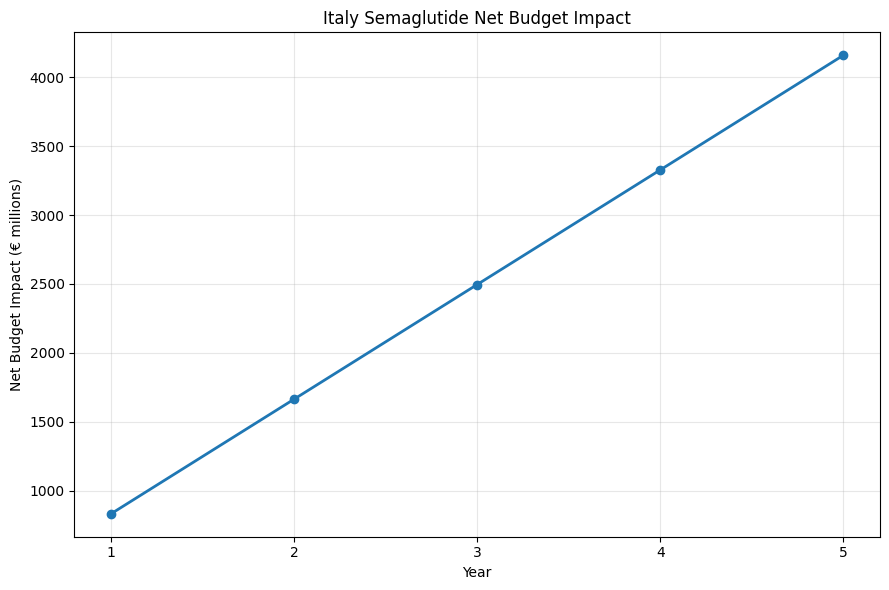

In [29]:
# ============================================================
# ITALY BUDGET IMPACT FIGURE
# ============================================================

import matplotlib.pyplot as plt

italy_figures = Path("../reports/italy/figures")
italy_figures.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    italy_model["Year"],
    italy_model["Net Budget Impact"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Net Budget Impact (€ millions)")
plt.title("Italy Semaglutide Net Budget Impact")
plt.xticks(italy_model["Year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    italy_figures / "italy_budget_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# ============================================================
# ITALY - SENSITIVITY ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create output folders
italy_tables = Path("../reports/italy/tables")
italy_figures = Path("../reports/italy/figures")
italy_sensitivity = Path("../reports/italy/sensitivity")

italy_tables.mkdir(parents=True, exist_ok=True)
italy_figures.mkdir(parents=True, exist_ok=True)
italy_sensitivity.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# DRUG COST SENSITIVITY
# ------------------------------------------------------------

drug_cost_values = [
    italy_annual_drug_cost * 0.75,
    italy_annual_drug_cost * 0.90,
    italy_annual_drug_cost,
    italy_annual_drug_cost * 1.10,
    italy_annual_drug_cost * 1.25
]

drug_sensitivity = []

for cost in drug_cost_values:

    year1_treated = (
        italy_adults_with_obesity
        * italy_model.loc[0, "Uptake"]
    )

    year1_drug_cost = year1_treated * cost

    year1_offset = (
        year1_treated
        * italy_annual_healthcare_offset
    )

    year1_net_impact = (
        year1_drug_cost
        - year1_offset
    )

    drug_sensitivity.append({
        "Annual Drug Cost (€)": cost,
        "Year 1 Net Budget Impact (€)": year1_net_impact
    })

drug_sensitivity = pd.DataFrame(drug_sensitivity)

drug_sensitivity.to_csv(
    italy_sensitivity / "italy_drug_cost_sensitivity.csv",
    index=False
)


# ------------------------------------------------------------
# UPTAKE SENSITIVITY
# ------------------------------------------------------------

uptake_values = [
    0.025,
    0.05,
    0.10,
    0.15,
    0.25
]

uptake_sensitivity = []

for uptake in uptake_values:

    treated = italy_adults_with_obesity * uptake

    drug_cost = treated * italy_annual_drug_cost

    offset = treated * italy_annual_healthcare_offset

    net_impact = drug_cost - offset

    uptake_sensitivity.append({
        "Year 1 Uptake": uptake,
        "Treated Population": treated,
        "Year 1 Net Budget Impact (€)": net_impact
    })

uptake_sensitivity = pd.DataFrame(uptake_sensitivity)

uptake_sensitivity.to_csv(
    italy_sensitivity / "italy_uptake_sensitivity.csv",
    index=False
)


print("Italy sensitivity analysis completed.")
print()
print("Files created:")
print(" - italy_drug_cost_sensitivity.csv")
print(" - italy_uptake_sensitivity.csv")

Italy sensitivity analysis completed.

Files created:
 - italy_drug_cost_sensitivity.csv
 - italy_uptake_sensitivity.csv


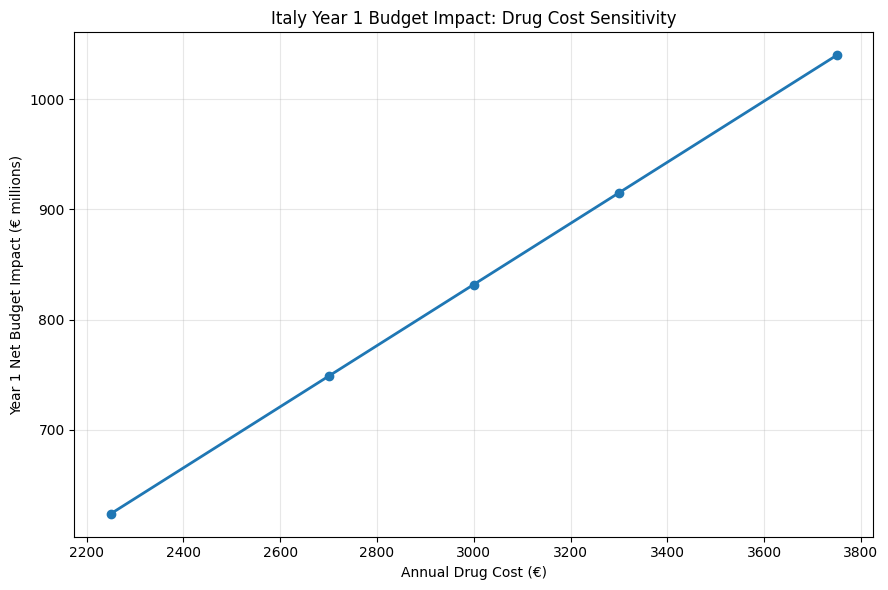

In [32]:
# ============================================================
# ITALY DRUG COST SENSITIVITY FIGURE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    drug_sensitivity["Annual Drug Cost (€)"],
    drug_sensitivity["Year 1 Net Budget Impact (€)"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.xlabel("Annual Drug Cost (€)")
plt.ylabel("Year 1 Net Budget Impact (€ millions)")
plt.title("Italy Year 1 Budget Impact: Drug Cost Sensitivity")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    italy_figures / "italy_price_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# ============================================================
# SAVE COMPLETE ITALY OUTPUTS
# ============================================================

italy_model.to_csv(
    italy_tables / "italy_budget_impact_summary.csv",
    index=False
)

italy_model_summary.to_csv(
    italy_tables / "italy_model_summary.csv",
    index=False
)

print("Italy outputs saved successfully.")
print()
print("Tables:")
for file in sorted(italy_tables.glob("*.csv")):
    print(" -", file.name)

print()
print("Figures:")
for file in sorted(italy_figures.glob("*.png")):
    print(" -", file.name)

print()
print("Sensitivity:")
for file in sorted(italy_sensitivity.glob("*.csv")):
    print(" -", file.name)

Italy outputs saved successfully.

Tables:
 - italy_adult_population_summary.csv
 - italy_budget_impact_summary.csv
 - italy_model_summary.csv

Figures:
 - italy_budget_impact.png
 - italy_price_sensitivity.png

Sensitivity:
 - italy_drug_cost_sensitivity.csv
 - italy_uptake_sensitivity.csv


In [34]:
# ============================================================
# UK vs USA vs ITALY COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "Adult Population",
        "Obesity Prevalence",
        "Adults with Obesity",
        "Annual Drug Cost",
        "Year 1 Uptake",
        "Year 5 Uptake",
        "Year 1 Net Budget Impact",
        "Year 5 Net Budget Impact"
    ],

    "United Kingdom": [
        55022253,
        0.2990555,
        3290941,
        2500,
        0.05,
        0.25,
        394912800,
        1974564000
    ],

    "United States": [
        269763500,
        0.3306,
        89190830,
        17537.26,
        0.05,
        0.25,
        67469563908.79,
        337347819543.94
    ],

    "Italy": [
        italy_adult_population,
        italy_obesity_prevalence,
        italy_adults_with_obesity,
        italy_annual_drug_cost,
        italy_model.loc[0, "Uptake"],
        italy_model.loc[4, "Uptake"],
        italy_model.loc[0, "Net Budget Impact"],
        italy_model.loc[4, "Net Budget Impact"]
    ]
})

comparison

,Metric,United Kingdom,United States,Italy
0,Adult Population,5.502225e+07,2.697635e+08,4.700000e+07
1,Obesity Prevalence,2.990555e-01,3.306000e-01,1.180000e-01
2,Adults with Obesity,3.290941e+06,8.919083e+07,5.546000e+06
3,Annual Drug Cost,2.500000e+03,1.753726e+04,3.000000e+03
4,Year 1 Uptake,5.000000e-02,5.000000e-02,5.000000e-02
5,Year 5 Uptake,2.500000e-01,2.500000e-01,2.500000e-01
6,Year 1 Net Budget Impact,3.949128e+08,6.746956e+10,8.319000e+08
7,Year 5 Net Budget Impact,1.974564e+09,3.373478e+11,4.159500e+09


In [35]:
# ============================================================
# SAVE CROSS-COUNTRY COMPARISON
# ============================================================

comparison_path = Path("../reports/comparative")
comparison_path.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    comparison_path / "uk_usa_italy_comparison.csv",
    index=False
)

print("Saved:")
print(comparison_path / "uk_usa_italy_comparison.csv")

Saved:
..\reports\comparative\uk_usa_italy_comparison.csv


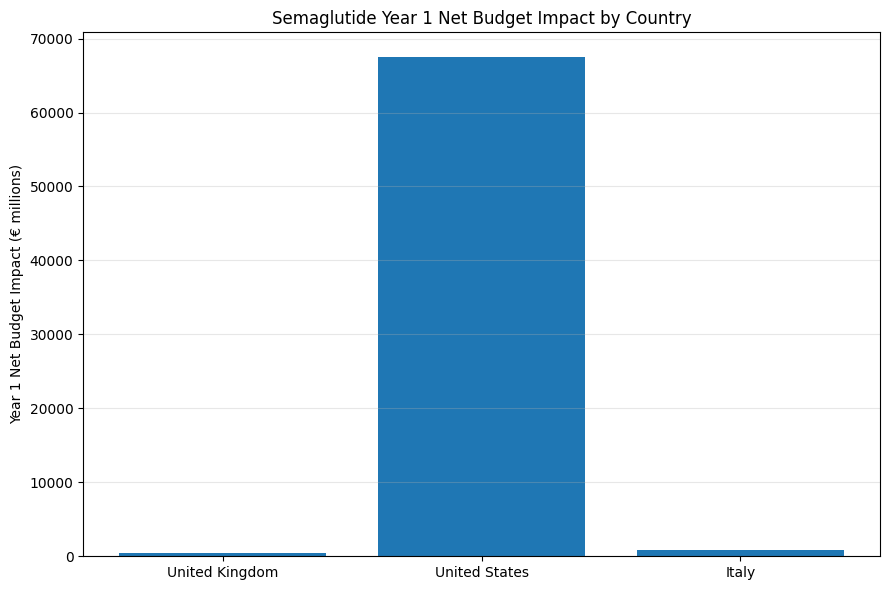

In [36]:
# ============================================================
# CROSS-COUNTRY YEAR 1 BUDGET IMPACT
# ============================================================

countries = [
    "United Kingdom",
    "United States",
    "Italy"
]

year1_impacts = [
    comparison.loc[
        comparison["Metric"] == "Year 1 Net Budget Impact",
        "United Kingdom"
    ].iloc[0],

    comparison.loc[
        comparison["Metric"] == "Year 1 Net Budget Impact",
        "United States"
    ].iloc[0],

    comparison.loc[
        comparison["Metric"] == "Year 1 Net Budget Impact",
        "Italy"
    ].iloc[0]
]

plt.figure(figsize=(9, 6))

plt.bar(
    countries,
    np.array(year1_impacts) / 1_000_000
)

plt.ylabel("Year 1 Net Budget Impact (€ millions)")
plt.title("Semaglutide Year 1 Net Budget Impact by Country")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    comparison_path / "year1_budget_impact_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

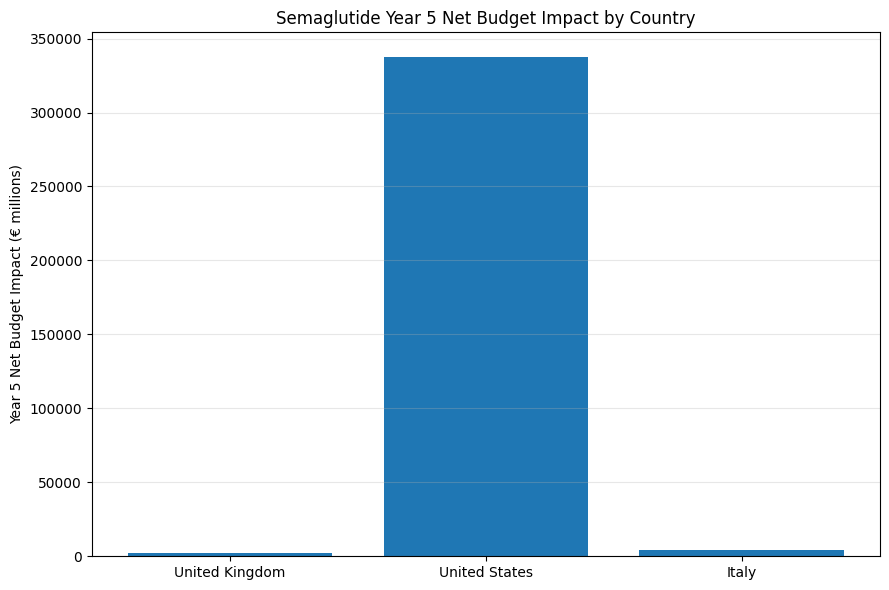

In [37]:
# ============================================================
# FIVE-YEAR BUDGET IMPACT COMPARISON
# ============================================================

year5_impacts = [
    comparison.loc[
        comparison["Metric"] == "Year 5 Net Budget Impact",
        "United Kingdom"
    ].iloc[0],

    comparison.loc[
        comparison["Metric"] == "Year 5 Net Budget Impact",
        "United States"
    ].iloc[0],

    comparison.loc[
        comparison["Metric"] == "Year 5 Net Budget Impact",
        "Italy"
    ].iloc[0]
]

plt.figure(figsize=(9, 6))

plt.bar(
    countries,
    np.array(year5_impacts) / 1_000_000
)

plt.ylabel("Year 5 Net Budget Impact (€ millions)")
plt.title("Semaglutide Year 5 Net Budget Impact by Country")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    comparison_path / "year5_budget_impact_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# ============================================================
# FINAL ITALY CHECK
# ============================================================

print("=" * 60)
print("ITALY SEMAGLUTIDE BUDGET IMPACT MODEL")
print("=" * 60)

print(
    f"Adult population: "
    f"{italy_adult_population:,.0f}"
)

print(
    f"Obesity prevalence: "
    f"{italy_obesity_prevalence:.1%}"
)

print(
    f"Adults with obesity: "
    f"{italy_adults_with_obesity:,.0f}"
)

print(
    f"Annual drug cost: "
    f"€{italy_annual_drug_cost:,.2f}"
)

print()

print(
    f"Year 1 treated population: "
    f"{italy_model.loc[0, 'Treated Population']:,.0f}"
)

print(
    f"Year 5 treated population: "
    f"{italy_model.loc[4, 'Treated Population']:,.0f}"
)

print()

print(
    f"Year 1 net budget impact: "
    f"€{italy_model.loc[0, 'Net Budget Impact']:,.2f}"
)

print(
    f"Year 5 net budget impact: "
    f"€{italy_model.loc[4, 'Net Budget Impact']:,.2f}"
)

print()
print("=" * 60)
print("ITALY MODEL COMPLETE")
print("=" * 60)

ITALY SEMAGLUTIDE BUDGET IMPACT MODEL
Adult population: 47,000,000
Obesity prevalence: 11.8%
Adults with obesity: 5,546,000
Annual drug cost: €3,000.00

Year 1 treated population: 277,300
Year 5 treated population: 1,386,500

Year 1 net budget impact: €831,900,000.00
Year 5 net budget impact: €4,159,500,000.00

ITALY MODEL COMPLETE


In [39]:
from pathlib import Path

italy_report = Path("../reports/italy")

print("Italy report folder exists:", italy_report.exists())

print("\n--- Tables ---")
for f in sorted((italy_report / "tables").glob("*")):
    print(f.name)

print("\n--- Figures ---")
for f in sorted((italy_report / "figures").glob("*")):
    print(f.name)

print("\n--- Sensitivity ---")
for f in sorted((italy_report / "sensitivity").glob("*")):
    print(f.name)

Italy report folder exists: True

--- Tables ---
italy_adult_population_summary.csv
italy_budget_impact_summary.csv
italy_model_summary.csv

--- Figures ---
italy_budget_impact.png
italy_price_sensitivity.png

--- Sensitivity ---
italy_drug_cost_sensitivity.csv
italy_uptake_sensitivity.csv


In [ ]:
# ============================================================
# ITALY UPTAKE SENSITIVITY FIGURE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

italy_figures = Path("../reports/italy/figures")
italy_figures.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    italy_uptake_sensitivity["Year 1 Uptake"] * 100,
    italy_uptake_sensitivity["Year 1 Net Budget Impact (€)"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.xlabel("Year 1 Uptake (%)")
plt.ylabel("Year 1 Net Budget Impact (€ millions)")
plt.title("Italy Year 1 Budget Impact: Uptake Sensitivity")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    italy_figures / "italy_uptake_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(italy_figures / "italy_uptake_sensitivity.png")

SyntaxError: invalid syntax (3993055749.py, line 1)

In [42]:
# ============================================================
# ITALY UPTAKE SENSITIVITY FIGURE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

italy_figures = Path("../reports/italy/figures")
italy_figures.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    italy_uptake_sensitivity["Year 1 Uptake"] * 100,
    italy_uptake_sensitivity["Year 1 Net Budget Impact (€)"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.xlabel("Year 1 Uptake (%)")
plt.ylabel("Year 1 Net Budget Impact (€ millions)")
plt.title("Italy Year 1 Budget Impact: Uptake Sensitivity")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    italy_figures / "italy_uptake_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(italy_figures / "italy_uptake_sensitivity.png")

NameError: name 'italy_uptake_sensitivity' is not defined

<Figure size 900x600 with 0 Axes>

In [43]:
print(italy_uptake_sensitivity)
print()
print("Rows:", len(italy_uptake_sensitivity))
print("Columns:", italy_uptake_sensitivity.columns.tolist())


NameError: name 'italy_uptake_sensitivity' is not defined

In [44]:
# ============================================================
# RECREATE ITALY UPTAKE SENSITIVITY
# ============================================================

italy_uptake_values = [0.025, 0.05, 0.10, 0.15, 0.25]

italy_uptake_sensitivity = []

for uptake in italy_uptake_values:

    treated_population = (
        italy_adults_with_obesity * uptake
    )

    drug_cost = (
        treated_population * italy_annual_drug_cost
    )

    healthcare_offset = (
        treated_population * italy_annual_healthcare_offset
    )

    net_budget_impact = (
        drug_cost - healthcare_offset
    )

    italy_uptake_sensitivity.append({
        "Year 1 Uptake": uptake,
        "Treated Population": treated_population,
        "Year 1 Net Budget Impact (€)": net_budget_impact
    })

italy_uptake_sensitivity = pd.DataFrame(
    italy_uptake_sensitivity
)

print(italy_uptake_sensitivity)


   Year 1 Uptake  Treated Population  Year 1 Net Budget Impact (€)
0          0.025            138650.0                  4.159500e+08
1          0.050            277300.0                  8.319000e+08
2          0.100            554600.0                  1.663800e+09
3          0.150            831900.0                  2.495700e+09
4          0.250           1386500.0                  4.159500e+09


In [45]:
# Save Italy uptake sensitivity table

italy_uptake_sensitivity.to_csv(
    "../reports/italy/sensitivity/italy_uptake_sensitivity.csv",
    index=False
)

print("Italy uptake sensitivity table saved successfully.")

Italy uptake sensitivity table saved successfully.


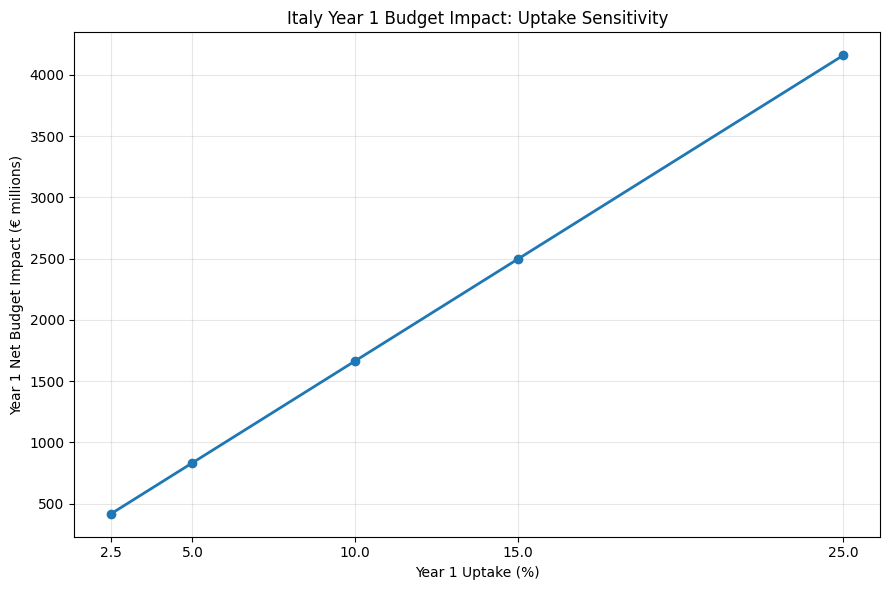

Figure saved successfully.


In [46]:
# ============================================================
# ITALY UPTAKE SENSITIVITY FIGURE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

italy_figures = Path("../reports/italy/figures")
italy_figures.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    italy_uptake_sensitivity["Year 1 Uptake"] * 100,
    italy_uptake_sensitivity["Year 1 Net Budget Impact (€)"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.xlabel("Year 1 Uptake (%)")
plt.ylabel("Year 1 Net Budget Impact (€ millions)")
plt.title("Italy Year 1 Budget Impact: Uptake Sensitivity")

plt.xticks([2.5, 5, 10, 15, 25])
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    italy_figures / "italy_uptake_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

In [47]:
# ============================================================
# ITALY FINAL RESULTS CHECK
# ============================================================

print("ITALY FINAL RESULTS")
print("=" * 50)

print(
    "Adult population:",
    f"{italy_adult_population:,.0f}"
)

print(
    "Obesity prevalence:",
    f"{italy_obesity_prevalence:.1%}"
)

print(
    "Adults with obesity:",
    f"{italy_adults_with_obesity:,.0f}"
)

print(
    "Annual drug cost:",
    f"€{italy_annual_drug_cost:,.2f}"
)

print()

print(
    "Year 1 uptake:",
    f"{italy_model.loc[0, 'Uptake']:.1%}"
)

print(
    "Year 1 treated population:",
    f"{italy_model.loc[0, 'Treated Population']:,.0f}"
)

print(
    "Year 1 net budget impact:",
    f"€{italy_model.loc[0, 'Net Budget Impact']:,.2f}"
)

print()

print(
    "Year 5 uptake:",
    f"{italy_model.loc[4, 'Uptake']:.1%}"
)

print(
    "Year 5 treated population:",
    f"{italy_model.loc[4, 'Treated Population']:,.0f}"
)

print(
    "Year 5 net budget impact:",
    f"€{italy_model.loc[4, 'Net Budget Impact']:,.2f}"
)

print("=" * 50)

ITALY FINAL RESULTS
Adult population: 47,000,000
Obesity prevalence: 11.8%
Adults with obesity: 5,546,000
Annual drug cost: €3,000.00

Year 1 uptake: 5.0%
Year 1 treated population: 277,300
Year 1 net budget impact: €831,900,000.00

Year 5 uptake: 25.0%
Year 5 treated population: 1,386,500
Year 5 net budget impact: €4,159,500,000.00


In [48]:
italy_model[
    [
        "Year",
        "Uptake",
        "Eligible Population",
        "Treated Population",
        "Drug Cost",
        "Healthcare Offset",
        "Net Budget Impact"
    ]
]

,Year,Uptake,Eligible Population,Treated Population,Drug Cost,Healthcare Offset,Net Budget Impact
0,1,0.05,5546000.0,277300.0,8.319000e+08,0.0,8.319000e+08
1,2,0.10,5546000.0,554600.0,1.663800e+09,0.0,1.663800e+09
2,3,0.15,5546000.0,831900.0,2.495700e+09,0.0,2.495700e+09
3,4,0.20,5546000.0,1109200.0,3.327600e+09,0.0,3.327600e+09
4,5,0.25,5546000.0,1386500.0,4.159500e+09,0.0,4.159500e+09


In [49]:
from pathlib import Path
import pandas as pd

italy_adult_file = Path("../reports/italy/tables/italy_adult_population_summary.csv")

print("File exists:", italy_adult_file.exists())

italy_adult_check = pd.read_csv(italy_adult_file)

print("\nItaly adult population table:")
display(italy_adult_check)

File exists: True

Italy adult population table:


,Metric,Value
0,Adult population (18+),50327351


In [50]:
italy_adult_population = 47_000_000

print("Current Italy adult population:", italy_adult_population)

Current Italy adult population: 47000000


In [52]:
italy_eligible_population = (
    italy_adult_population * italy_obesity_prevalence
)

print(f"Italy adult population: {italy_adult_population:,.0f}")
print(f"Italy obesity prevalence: {italy_obesity_prevalence:.1%}")
print(f"Italy eligible population: {italy_eligible_population:,.0f}")

Italy adult population: 47,000,000
Italy obesity prevalence: 11.8%
Italy eligible population: 5,546,000


In [53]:
italy_model = pd.DataFrame({
    "Year": [1, 2, 3, 4, 5],
    "Uptake": [0.05, 0.10, 0.15, 0.20, 0.25]
})

italy_model["Eligible Population"] = italy_eligible_population

italy_model["Treated Population"] = (
    italy_model["Eligible Population"] * italy_model["Uptake"]
).round()

italy_model["Drug Cost"] = (
    italy_model["Treated Population"] * italy_annual_drug_cost
)

italy_model["Healthcare Offset"] = (
    italy_model["Treated Population"] * italy_annual_healthcare_offset
)

italy_model["Net Budget Impact"] = (
    italy_model["Drug Cost"] - italy_model["Healthcare Offset"]
)

display(italy_model)

,Year,Uptake,Eligible Population,Treated Population,Drug Cost,Healthcare Offset,Net Budget Impact
0,1,0.05,5546000.0,277300.0,8.319000e+08,0.0,8.319000e+08
1,2,0.10,5546000.0,554600.0,1.663800e+09,0.0,1.663800e+09
2,3,0.15,5546000.0,831900.0,2.495700e+09,0.0,2.495700e+09
3,4,0.20,5546000.0,1109200.0,3.327600e+09,0.0,3.327600e+09
4,5,0.25,5546000.0,1386500.0,4.159500e+09,0.0,4.159500e+09


In [54]:
# Check the existing Italy adult-population output
italy_adult_file = "../reports/italy/tables/italy_adult_population_summary.csv"

italy_adult_check = pd.read_csv(italy_adult_file)

display(italy_adult_check)

,Metric,Value
0,Adult population (18+),50327351


In [55]:
# Exact Italy adult population from the existing population output
italy_adult_population = 50_327_351

# Italy obesity prevalence
italy_obesity_prevalence = 0.118

# Recalculate eligible population
italy_eligible_population = round(
    italy_adult_population * italy_obesity_prevalence
)

print(f"Adult population (18+): {italy_adult_population:,}")
print(f"Obesity prevalence: {italy_obesity_prevalence:.1%}")
print(f"Eligible population: {italy_eligible_population:,}")

Adult population (18+): 50,327,351
Obesity prevalence: 11.8%
Eligible population: 5,938,627


In [56]:
italy_model = pd.DataFrame({
    "Year": [1, 2, 3, 4, 5],
    "Uptake": [0.05, 0.10, 0.15, 0.20, 0.25]
})

italy_model["Eligible Population"] = italy_eligible_population

italy_model["Treated Population"] = (
    italy_model["Eligible Population"] * italy_model["Uptake"]
).round()

italy_model["Drug Cost"] = (
    italy_model["Treated Population"] * italy_annual_drug_cost
)

italy_model["Healthcare Offset"] = (
    italy_model["Treated Population"] * italy_annual_healthcare_offset
)

italy_model["Net Budget Impact"] = (
    italy_model["Drug Cost"] - italy_model["Healthcare Offset"]
)

display(italy_model)

,Year,Uptake,Eligible Population,Treated Population,Drug Cost,Healthcare Offset,Net Budget Impact
0,1,0.05,5938627,296931.0,8.907930e+08,0.0,8.907930e+08
1,2,0.10,5938627,593863.0,1.781589e+09,0.0,1.781589e+09
2,3,0.15,5938627,890794.0,2.672382e+09,0.0,2.672382e+09
3,4,0.20,5938627,1187725.0,3.563175e+09,0.0,3.563175e+09
4,5,0.25,5938627,1484657.0,4.453971e+09,0.0,4.453971e+09


In [57]:
from pathlib import Path

italy_tables_dir = Path("../reports/italy/tables")
italy_tables_dir.mkdir(parents=True, exist_ok=True)

# Save corrected main model
italy_model.to_csv(
    italy_tables_dir / "italy_model_summary.csv",
    index=False
)

print("Saved:")
print(italy_tables_dir / "italy_model_summary.csv")

Saved:
..\reports\italy\tables\italy_model_summary.csv


In [58]:
italy_adult_population_summary = pd.DataFrame({
    "Metric": ["Adult population (18+)"],
    "Value": [italy_adult_population]
})

italy_adult_population_summary.to_csv(
    italy_tables_dir / "italy_adult_population_summary.csv",
    index=False
)

display(italy_adult_population_summary)

,Metric,Value
0,Adult population (18+),50327351


In [59]:
italy_budget_impact_summary = italy_model[
    [
        "Year",
        "Uptake",
        "Eligible Population",
        "Treated Population",
        "Drug Cost",
        "Healthcare Offset",
        "Net Budget Impact"
    ]
].copy()

italy_budget_impact_summary.to_csv(
    italy_tables_dir / "italy_budget_impact_summary.csv",
    index=False
)

display(italy_budget_impact_summary)

,Year,Uptake,Eligible Population,Treated Population,Drug Cost,Healthcare Offset,Net Budget Impact
0,1,0.05,5938627,296931.0,8.907930e+08,0.0,8.907930e+08
1,2,0.10,5938627,593863.0,1.781589e+09,0.0,1.781589e+09
2,3,0.15,5938627,890794.0,2.672382e+09,0.0,2.672382e+09
3,4,0.20,5938627,1187725.0,3.563175e+09,0.0,3.563175e+09
4,5,0.25,5938627,1484657.0,4.453971e+09,0.0,4.453971e+09


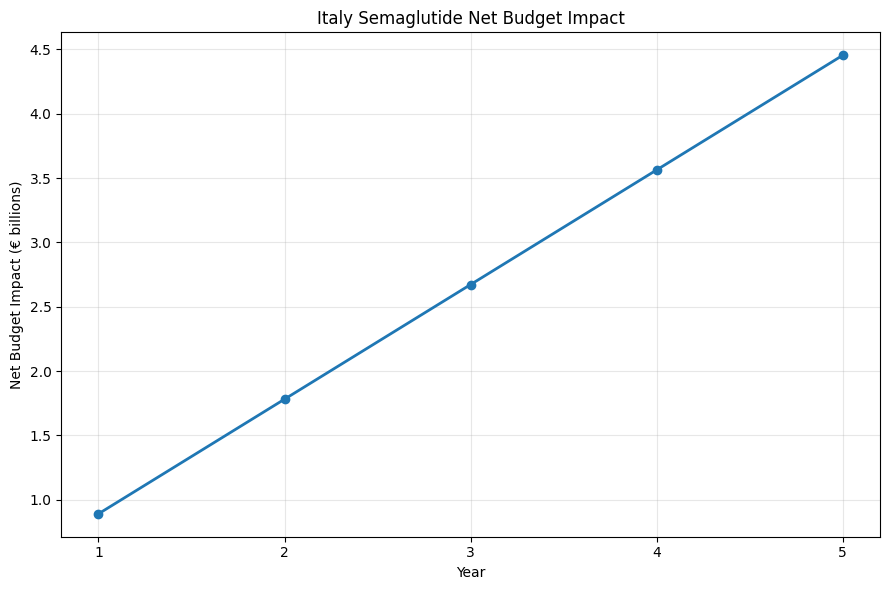

Saved: ..\reports\italy\figures\italy_budget_impact.png


In [60]:
import matplotlib.pyplot as plt
from pathlib import Path

italy_figures_dir = Path("../reports/italy/figures")
italy_figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    italy_model["Year"],
    italy_model["Net Budget Impact"] / 1e9,
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Net Budget Impact (€ billions)")
plt.title("Italy Semaglutide Net Budget Impact")
plt.xticks(italy_model["Year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()

italy_budget_fig = italy_figures_dir / "italy_budget_impact.png"

plt.savefig(
    italy_budget_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", italy_budget_fig)

In [61]:
print("Figure exists:", italy_budget_fig.exists())
print("Figure path:", italy_budget_fig)

Figure exists: True
Figure path: ..\reports\italy\figures\italy_budget_impact.png


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

italy_sensitivity_dir = Path("../reports/italy/sensitivity")
italy_figures_dir = Path("../reports/italy/figures")

italy_sensitivity_dir.mkdir(parents=True, exist_ok=True)
italy_figures_dir.mkdir(parents=True, exist_ok=True)

# Annual drug costs tested around the €3,000 base case
drug_costs = np.array([
    2000,
    2500,
    3000,
    3500,
    4000
])

# Year 1 uptake
year1_uptake = 0.05

# Correct calculation of treated population
year1_treated_population = round(
    italy_eligible_population * year1_uptake
)

italy_price_sensitivity = pd.DataFrame({
    "Drug Cost": drug_costs,
    "Year 1 Treated Population": year1_treated_population
})

# Calculate Year 1 budget impact
italy_price_sensitivity["Year 1 Budget Impact"] = (
    italy_price_sensitivity["Year 1 Treated Population"]
    * italy_price_sensitivity["Drug Cost"]
)

# Save sensitivity table
italy_price_sensitivity.to_csv(
    italy_sensitivity_dir / "italy_drug_cost_sensitivity.csv",
    index=False
)

display(italy_price_sensitivity)

,Drug Cost,Year 1 Treated Population,Year 1 Budget Impact
0,2000,296931,593862000
1,2500,296931,742327500
2,3000,296931,890793000
3,3500,296931,1039258500
4,4000,296931,1187724000


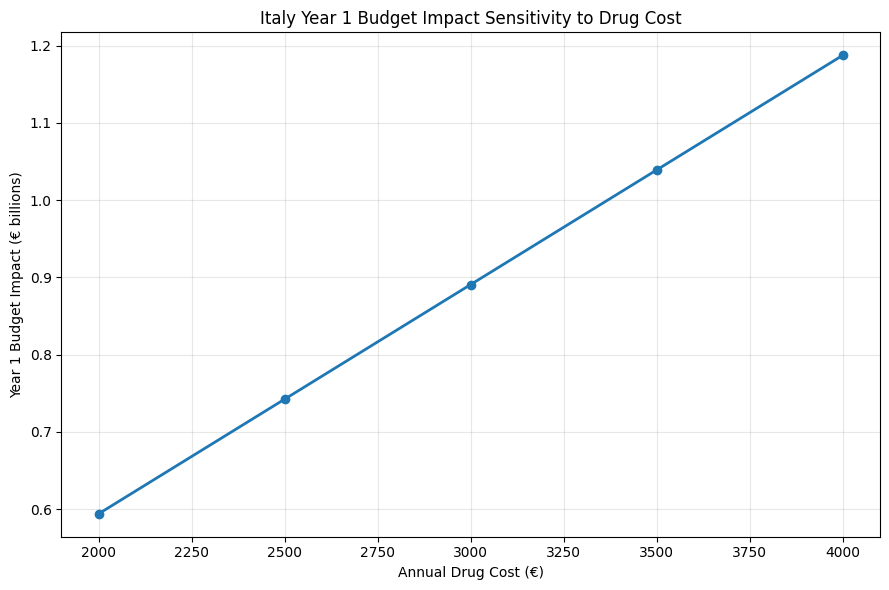

Saved: ..\reports\italy\figures\italy_price_sensitivity.png


In [65]:
# Italy price sensitivity figure

plt.figure(figsize=(9, 6))

plt.plot(
    italy_price_sensitivity["Drug Cost"],
    italy_price_sensitivity["Year 1 Budget Impact"] / 1e9,
    marker="o",
    linewidth=2
)

plt.xlabel("Annual Drug Cost (€)")
plt.ylabel("Year 1 Budget Impact (€ billions)")
plt.title("Italy Year 1 Budget Impact Sensitivity to Drug Cost")
plt.grid(True, alpha=0.3)

plt.tight_layout()

italy_price_fig = italy_figures_dir / "italy_price_sensitivity.png"

plt.savefig(
    italy_price_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", italy_price_fig)

In [67]:
# Italy uptake sensitivity analysis

uptake_scenarios = np.array([
    0.03,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
])

italy_uptake_sensitivity = pd.DataFrame({
    "Uptake": uptake_scenarios
})

italy_uptake_sensitivity["Treated Population"] = (
    italy_eligible_population
    * italy_uptake_sensitivity["Uptake"]
).round()

italy_uptake_sensitivity["Year 1 Budget Impact"] = (
    italy_uptake_sensitivity["Treated Population"]
    * italy_annual_drug_cost
)

italy_uptake_sensitivity.to_csv(
    italy_sensitivity_dir / "italy_uptake_sensitivity.csv",
    index=False
)

display(italy_uptake_sensitivity)

,Uptake,Treated Population,Year 1 Budget Impact
0,0.03,178159.0,5.344770e+08
1,0.05,296931.0,8.907930e+08
2,0.10,593863.0,1.781589e+09
3,0.15,890794.0,2.672382e+09
4,0.20,1187725.0,3.563175e+09
5,0.25,1484657.0,4.453971e+09
6,0.30,1781588.0,5.344764e+09


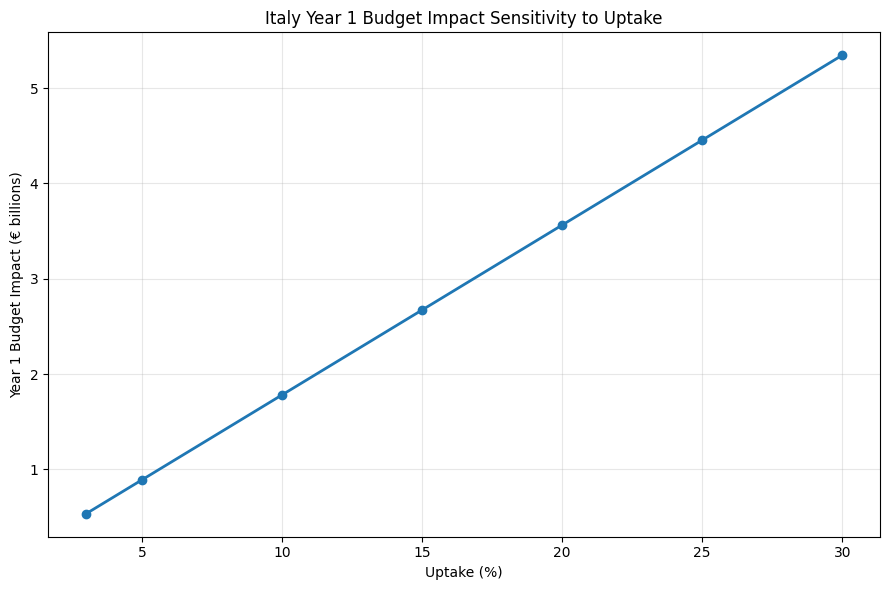

Saved: ..\reports\italy\figures\italy_uptake_sensitivity.png


In [68]:
plt.figure(figsize=(9, 6))

plt.plot(
    italy_uptake_sensitivity["Uptake"] * 100,
    italy_uptake_sensitivity["Year 1 Budget Impact"] / 1e9,
    marker="o",
    linewidth=2
)

plt.xlabel("Uptake (%)")
plt.ylabel("Year 1 Budget Impact (€ billions)")
plt.title("Italy Year 1 Budget Impact Sensitivity to Uptake")
plt.grid(True, alpha=0.3)

plt.tight_layout()

italy_uptake_fig = italy_figures_dir / "italy_uptake_sensitivity.png"

plt.savefig(
    italy_uptake_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", italy_uptake_fig)

In [69]:
italy_model_summary = pd.DataFrame({
    "Metric": [
        "Adult population (18+)",
        "Obesity prevalence",
        "Eligible population",
        "Annual drug cost per patient",
        "Annual healthcare offset per patient",
        "Year 1 uptake",
        "Year 5 uptake",
        "Year 1 treated population",
        "Year 5 treated population",
        "Year 1 net budget impact",
        "Year 5 net budget impact"
    ],
    "Value": [
        italy_adult_population,
        italy_obesity_prevalence,
        italy_eligible_population,
        italy_annual_drug_cost,
        italy_annual_healthcare_offset,
        0.05,
        0.25,
        italy_model.loc[italy_model["Year"] == 1, "Treated Population"].iloc[0],
        italy_model.loc[italy_model["Year"] == 5, "Treated Population"].iloc[0],
        italy_model.loc[italy_model["Year"] == 1, "Net Budget Impact"].iloc[0],
        italy_model.loc[italy_model["Year"] == 5, "Net Budget Impact"].iloc[0]
    ]
})

italy_model_summary.to_csv(
    italy_tables_dir / "italy_model_summary.csv",
    index=False
)

display(italy_model_summary)

,Metric,Value
0,Adult population (18+),5.032735e+07
1,Obesity prevalence,1.180000e-01
2,Eligible population,5.938627e+06
3,Annual drug cost per patient,3.000000e+03
4,Annual healthcare offset per patient,0.000000e+00
5,Year 1 uptake,5.000000e-02
6,Year 5 uptake,2.500000e-01
7,Year 1 treated population,2.969310e+05
8,Year 5 treated population,1.484657e+06
9,Year 1 net budget impact,8.907930e+08


In [70]:
italy_model_summary = pd.DataFrame({
    "Metric": [
        "Adult population (18+)",
        "Obesity prevalence",
        "Eligible population",
        "Annual drug cost per patient",
        "Annual healthcare offset per patient",
        "Year 1 uptake",
        "Year 5 uptake",
        "Year 1 treated population",
        "Year 5 treated population",
        "Year 1 net budget impact",
        "Year 5 net budget impact"
    ],
    "Value": [
        italy_adult_population,
        italy_obesity_prevalence,
        italy_eligible_population,
        italy_annual_drug_cost,
        italy_annual_healthcare_offset,
        0.05,
        0.25,
        italy_model.loc[italy_model["Year"] == 1, "Treated Population"].iloc[0],
        italy_model.loc[italy_model["Year"] == 5, "Treated Population"].iloc[0],
        italy_model.loc[italy_model["Year"] == 1, "Net Budget Impact"].iloc[0],
        italy_model.loc[italy_model["Year"] == 5, "Net Budget Impact"].iloc[0]
    ]
})

italy_model_summary.to_csv(
    italy_tables_dir / "italy_model_summary.csv",
    index=False
)

display(italy_model_summary)

,Metric,Value
0,Adult population (18+),5.032735e+07
1,Obesity prevalence,1.180000e-01
2,Eligible population,5.938627e+06
3,Annual drug cost per patient,3.000000e+03
4,Annual healthcare offset per patient,0.000000e+00
5,Year 1 uptake,5.000000e-02
6,Year 5 uptake,2.500000e-01
7,Year 1 treated population,2.969310e+05
8,Year 5 treated population,1.484657e+06
9,Year 1 net budget impact,8.907930e+08


In [71]:
print("===== FINAL ITALY MODEL =====")

print(f"Adult population (18+): {italy_adult_population:,.0f}")
print(f"Obesity prevalence: {italy_obesity_prevalence:.1%}")
print(f"Eligible population: {italy_eligible_population:,.0f}")

print(
    f"Year 1 treated population: "
    f"{italy_model.loc[italy_model['Year'] == 1, 'Treated Population'].iloc[0]:,.0f}"
)

print(
    f"Year 1 net budget impact: "
    f"€{italy_model.loc[italy_model['Year'] == 1, 'Net Budget Impact'].iloc[0]:,.2f}"
)

print(
    f"Year 5 treated population: "
    f"{italy_model.loc[italy_model['Year'] == 5, 'Treated Population'].iloc[0]:,.0f}"
)

print(
    f"Year 5 net budget impact: "
    f"€{italy_model.loc[italy_model['Year'] == 5, 'Net Budget Impact'].iloc[0]:,.2f}"
)

===== FINAL ITALY MODEL =====
Adult population (18+): 50,327,351
Obesity prevalence: 11.8%
Eligible population: 5,938,627
Year 1 treated population: 296,931
Year 1 net budget impact: €890,793,000.00
Year 5 treated population: 1,484,657
Year 5 net budget impact: €4,453,971,000.00
